# 📰 Analisis Sentimen Berita — Evaluasi 48 Tahun UNS
> **Muhammad Rifai | Portfolio | Data Analytics**

---

## Konteks & Sumber

**Judul berita:** *Evaluasi 48 Tahun UNS: Aliansi BEM UNS Gelar Panggung SEMAR dan Bagi Takjil*  
**Sumber:** [saluransebelas.com](https://saluransebelas.com/evaluasi-48-tahun-uns-aliansi-bem-uns-gelar-panggung-semar-dan-bagi-takjil/)  
**Tanggal:** 25 Maret 2024  
**Penulis:** Veri Nugroho dan Tiara Nur A.  
**Editor:** Dhiazwara Yusuf Dirga A.

---

## Problem

Berita ini meliput kegiatan Panggung Semar yang digelar Aliansi BEM UNS sebagai bentuk ekspresi aspirasi mahasiswa pada Dies Natalis UNS ke-48. Analisis ini menjawab:

1. **Sentimen keseluruhan** — apakah berita ini cenderung positif, negatif, atau netral?
2. **Sentimen per paragraf & kalimat** — bagian mana yang paling kritis/positif?
3. **Sentimen per narasumber** — bagaimana nada pernyataan tiap narasumber?
4. **Topic & keyword analysis** — isu apa yang paling dominan?
5. **Aspect-Based Sentiment** — sentimen per aspek (akademik, sarana, kebijakan, kegiatan)

## Metodologi
```
1. Text Preprocessing  → Tokenisasi, stopword removal, normalisasi
2. Lexicon-Based NLP   → Kamus sentimen Bahasa Indonesia domain kampus
3. Sentence-Level ABSA → Analisis per kalimat & per narasumber
4. Aspect-Based        → Sentimen per aspek (akademik, fasilitas, kebijakan, event)
5. Visualization       → Word frequency, sentiment heatmap, summary dashboard
```
---

In [1]:
# ─── Import Libraries ─────────────────────────────────────────────
import re
import json
import math
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ─── Styling ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0a0f1e',
    'axes.facecolor':   '#0a0f1e',
    'axes.edgecolor':   '#1e2a3e',
    'axes.labelcolor':  '#c8d8e8',
    'xtick.color':      '#c8d8e8',
    'ytick.color':      '#c8d8e8',
    'text.color':       '#c8d8e8',
    'grid.color':       '#1e2a3e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

BLUE   = '#4a9fd4'
GREEN  = '#4ecb8a'
RED    = '#e05c6e'
YELLOW = '#f5c842'
PURPLE = '#9b8dc4'
ORANGE = '#e89b4a'
TEAL   = '#7ec8c8'
GRAY   = '#6a7a8a'

SENT_COLORS = {'Positif': GREEN, 'Negatif': RED, 'Netral': YELLOW}

print('Libraries loaded!')

Libraries loaded!


---
## Section 1 — Input Teks & Preprocessing

In [2]:
# ─── Raw Text ─────────────────────────────────────────────────────
RAW_TEXT = """
Kamis (21/3), Aliansi Badan Eksekutif Mahasiswa (BEM) Universitas Sebelas Maret menggelar 
"Panggung Semar" bertajuk "Evaluasi 48 Tahun UNS" yang bertempat di Boulevard UNS. 
Panggung ini diisi dengan pertunjukan bakat seperti monolog puisi, orasi, drama, hingga 
penampilan band oleh perwakilan tiap fakultas. Selain penampilan bakat, Aliansi BEM UNS 
juga membagikan takjil ramadan gratis kepada mahasiswa dan masyarakat sekitar. 
Panggung Semar dimulai sejak pukul 15.30 hingga 18.00 sore yang dihadiri oleh puluhan mahasiswa.

Presiden BEM UNS, Agung Lucky mengatakan bahwa Panggung Semar ini dilaksanakan setiap tahun 
sebagai bentuk mahasiswa mengekspresikan aspirasi untuk UNS. Agung juga menjelaskan terkait 
perubahan lokasi yang sebelumnya bertempat di danau UNS tetapi mendadak pindah ke area Boulevard UNS.

"Tidak diketahui sebelumnya, ijin juga sudah dibuat dan masuk ke satpam serta rektorat dan disetujui. 
Ternyata hari-H itu tiba-tiba diketahui ada bentrok jadwal dengan acara dari kelompok lain di danau UNS. 
Akhirnya kita berpindah tempat dan mengalah ke Boulevard UNS," tutur Agung.

Panggung Semar ini diawali dengan pembacaan puisi oleh temen-teman Teater Tesa perwakilan dari 
Fakultas Ilmu Budaya (FIB). Kemudian dilanjutkan dengan orasi dari perwakilan Fakultas Hukum (FH), 
serta penampilan drama oleh perwakilan Fakultas Ilmu Sosial dan Politik (FISIP) dan beberapa 
penampilan bakat oleh fakultas lain.

Muhammad Rifai, mahasiswa Fakultas Matematika dan Ilmu Pengetahuan Alam (FMIPA) jurusan 
Statistika menjadi perwakilan pada Panggung Semar kali ini. Rifai bermonolog dengan puisi 
ciptaannya berjudul "Termenung".

"Maknanya tentang mahasiswa yang termenung, bangga masuk UNS tapi dia susah untuk mengekspresikan 
diri. Alasan keterbatasan seperti sarana prasarana dan lainnya buat dia mengekspresikan sebuah karya," 
jelasnya perihal monolog yang bawakan.

Muhammad Rifai juga memberikan harapan kepada UNS agar menjadi lebih baik dan lebih maju kedepannya. 
Rifai juga berharap kepada petinggi kampus UNS supaya lebih terbuka dan menindaklanjuti 
aspirasi-aspirasi dari mahasiswa.

Tanggapan juga diberikan oleh Lukman sebagai Wakil Presiden BEM UNS. Lukman mengatakan bahwa 
panggung ini merupakan wujud kecintaan keluarga besar mahasiswa UNS sebagai hadiah untuk perayaan 
Dies Natalis UNS ke-48. Dia menegaskan bentuk wujud kecintaan itu adalah mengingatkan pimpinan 
kampus untuk lebih memperhatikan kebijakan yang berorientasi pada mutu pendidikan. Mutu pendidikan 
yang dimaksud adalah proses seleksi masuk, kualitas tenaga pendidik, dan sarana prasarana penunjang pembelajaran.

"Hari ini atas nama BEM UNS, saya memberikan rapor merah kepada Pimpinan UNS karena 
ketidakberhasilannya dalam menangani permasalahan yang ada di UNS seperti penghapusan SPI 0 rupiah 
bagi kuota mandiri dan sarana prasarana yang kurang mendukung pembelajaran," pungkas Lukman.
"""

print(f'Panjang teks : {len(RAW_TEXT)} karakter')
print(f'Jumlah kata  : {len(RAW_TEXT.split())}')
print(f'Jumlah paragraf: {len([p for p in RAW_TEXT.strip().split(chr(10)+chr(10)) if p.strip()])}')

Panjang teks : 2900 karakter
Jumlah kata  : 387
Jumlah paragraf: 9


In [3]:
# ─── Stopwords Bahasa Indonesia ───────────────────────────────────
STOPWORDS = {
    'yang','dan','di','ke','dari','ini','itu','ada','dengan','untuk','pada','dalam',
    'adalah','juga','oleh','atau','tidak','akan','telah','sudah','serta','sebagai',
    'dari','agar','atas','bagi','tapi','tapi','namun','tetapi','karena','saat','ketika',
    'pun','pula','bahwa','jika','maka','hanya','kita','dia','mereka','kami','anda',
    'saya','kamu','ia','nya','si','ber','me','ke','ter','pe','per','an','kan','lah',
    'hingga','sejak','setelah','sebelum','setiap','lain','beberapa','teman','para',
    'lebih','sangat','paling','cukup','agak','sekali','antara','selain','seperti',
    'hal','cara','pihak','waktu','hari','tahun','bulan','tempat','lokasi','area',
    'kali','itu','ini','jadi','menjadi','tentang','terkait','perihal','tutur','pungkas',
    'kata','ujar','ungkap','jelasnya','mengatakan','menyatakan','menjelaskan','diketahui',
    'sudah','sudah','dibuat','masuk','pindah','mengalah','diawali','dilanjutkan',
    'diisi','dimulai','dihadiri','diberikan','merupakan','bertempat','bertajuk'
}

def preprocess(text):
    """Tokenisasi, lowercase, hapus stopwords & angka."""
    text  = text.lower()
    text  = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens= re.findall(r'\b[a-z]{3,}\b', text)
    tokens= [t for t in tokens if t not in STOPWORDS]
    return tokens

all_tokens = preprocess(RAW_TEXT)
token_freq = Counter(all_tokens)

print(f'Total token (setelah stopword removal): {len(all_tokens)}')
print(f'Unique tokens: {len(token_freq)}')
print(f'\nTop 20 kata:')
for word, count in token_freq.most_common(20):
    print(f'  {word:<25} {count}')

Total token (setelah stopword removal): 242
Unique tokens: 147

Top 20 kata:
  uns                       18
  mahasiswa                 8
  panggung                  7
  fakultas                  6
  bem                       5
  semar                     5
  perwakilan                5
  penampilan                4
  kepada                    4
  rifai                     4
  boulevard                 3
  bakat                     3
  puisi                     3
  agung                     3
  mengekspresikan           3
  aspirasi                  3
  ilmu                      3
  sarana                    3
  prasarana                 3
  lukman                    3


---
## 🔵 Section 2 — Lexicon-Based Sentiment Analysis

In [4]:
# ─── Kamus Sentimen Bahasa Indonesia (Domain: Kampus/Berita) ──────
LEXICON_POS = {
    # Ekspresi positif umum
    'bangga':2, 'harapan':2, 'berharap':2, 'semangat':2, 'kecintaan':2,
    'antusias':2, 'peduli':1, 'kreativitas':2, 'inovatif':2, 'bakat':1,
    'kualitas':1, 'mutu':1, 'baik':1, 'maju':2, 'terbuka':1, 'apresiasi':2,
    'mendukung':1, 'meriah':2, 'gratis':1, 'hadiah':2, 'disetujui':1,
    # Domain kegiatan
    'aspirasi':1, 'ekspresi':1, 'mengekspresikan':1, 'partisipasi':1,
    'penampilan':1, 'pertunjukan':1, 'kreatif':2,
    # Domain pendidikan
    'memperhatikan':1, 'menindaklanjuti':1, 'berorientasi':1, 'perayaan':1,
    'wujud':1, 'kecintaan':2,
    # Kata kerja positif
    'membagikan':1, 'memberikan':1, 'mewakili':1, 'mengingatkan':1,
}

LEXICON_NEG = {
    # Evaluasi negatif
    'merah':3, 'rapor':2, 'ketidakberhasilannya':3, 'gagal':3, 'buruk':3,
    'permasalahan':2, 'masalah':2, 'keluhan':2, 'kecewa':3, 'marah':2,
    # Keterbatasan
    'kurang':2, 'susah':2, 'keterbatasan':2, 'kekurangan':2, 'terbatas':1,
    'lemah':2, 'minim':2, 'rendah':1,
    # Kejadian negatif
    'bentrok':2, 'mendadak':1, 'mengalah':1, 'penghapusan':2,
    'termenung':1, 'protes':2, 'evaluasi':1, 'kritik':2, 'kritis':1,
    # Negasi
    'tidak':1, 'belum':1, 'tanpa':1,
}

NEGATION_WORDS = {'tidak','bukan','belum','tanpa','jangan','kurang'}
INTENSIFIER = {'sangat':1.5,'sekali':1.3,'paling':1.4,'cukup':0.8,'agak':0.7}

def sentiment_score(text):
    """Hitung sentiment score dengan bobot lexicon + negasi + intensifier."""
    text_clean = text.lower()
    text_clean = re.sub(r'[^a-zA-Z\s]', ' ', text_clean)
    tokens = text_clean.split()
    
    pos_score, neg_score = 0, 0
    pos_words, neg_words = [], []
    
    for i, token in enumerate(tokens):
        # Cek intensifier sebelum kata ini
        multiplier = 1.0
        if i > 0 and tokens[i-1] in INTENSIFIER:
            multiplier = INTENSIFIER[tokens[i-1]]
        
        # Cek negasi (2 kata sebelum)
        negated = any(tokens[max(0,i-j)] in NEGATION_WORDS for j in range(1,3))
        
        if token in LEXICON_POS:
            score = LEXICON_POS[token] * multiplier
            if negated:
                neg_score += score * 0.5
                neg_words.append(f'~{token}')
            else:
                pos_score += score
                pos_words.append(token)
        
        elif token in LEXICON_NEG:
            score = LEXICON_NEG[token] * multiplier
            if negated:
                pos_score += score * 0.5
                pos_words.append(f'~{token}')
            else:
                neg_score += score
                neg_words.append(token)
    
    total = pos_score + neg_score
    compound = (pos_score - neg_score) / max(total, 1)
    
    if compound > 0.15:
        label = 'Positif'
    elif compound < -0.15:
        label = 'Negatif'
    else:
        label = 'Netral'
    
    return {
        'pos_score': round(pos_score, 2),
        'neg_score': round(neg_score, 2),
        'compound':  round(compound, 4),
        'label':     label,
        'pos_words': pos_words,
        'neg_words': neg_words
    }

# Test
test_pos = 'Mahasiswa bangga dan antusias mewakili fakultas dalam penampilan yang meriah'
test_neg = 'Rapor merah diberikan karena ketidakberhasilannya menangani permasalahan kampus'
print('Test Positif:', sentiment_score(test_pos))
print('Test Negatif:', sentiment_score(test_neg))

Test Positif: {'pos_score': 8.0, 'neg_score': 0, 'compound': 1.0, 'label': 'Positif', 'pos_words': ['bangga', 'antusias', 'mewakili', 'penampilan', 'meriah'], 'neg_words': []}
Test Negatif: {'pos_score': 0, 'neg_score': 10.0, 'compound': -1.0, 'label': 'Negatif', 'pos_words': [], 'neg_words': ['rapor', 'merah', 'ketidakberhasilannya', 'permasalahan']}


In [6]:
# ─── Segmentasi Teks ke Paragraf & Kalimat ────────────────────────
paragraphs_raw = [p.strip() for p in RAW_TEXT.strip().split('\n\n') if p.strip()]

# Label paragraf
para_labels = [
    'P1: Pembukaan — Deskripsi Acara',
    'P2: Pernyataan Agung (Presiden BEM) — Konteks Lokasi',
    'P3: Kutipan Agung — Perubahan Lokasi',
    'P4: Rundown Acara — Penampilan Tiap Fakultas',
    'P5: Profil Rifai — Perwakilan FMIPA',
    'P6: Kutipan Rifai — Makna Puisi Termenung',
    'P7: Harapan Rifai untuk UNS',
    'P8: Pernyataan Lukman (Wakil Presiden BEM)',
    'P9: Kutipan Lukman — Rapor Merah UNS',
]

df_para = pd.DataFrame({
    'id':    range(1, len(paragraphs_raw)+1),
    'label': para_labels[:len(paragraphs_raw)],
    'text':  paragraphs_raw
})

# Analisis sentimen per paragraf
results = [sentiment_score(p) for p in df_para['text']]
df_para['pos_score'] = [r['pos_score'] for r in results]
df_para['neg_score'] = [r['neg_score'] for r in results]
df_para['compound']  = [r['compound']  for r in results]
df_para['label_sent']= [r['label']     for r in results]
df_para['pos_words'] = [r['pos_words'] for r in results]
df_para['neg_words'] = [r['neg_words'] for r in results]
df_para['word_count']= df_para['text'].apply(lambda x: len(x.split()))

print('Analisis Sentimen per Paragraf:')
display(df_para[['id','label','compound','label_sent','pos_score','neg_score']].to_string())

Analisis Sentimen per Paragraf:


'   id                                                 label  compound label_sent  pos_score  neg_score\n0   1                       P1: Pembukaan — Deskripsi Acara    0.7500    Positif        7.0        1.0\n1   2  P2: Pernyataan Agung (Presiden BEM) — Konteks Lokasi    0.3333    Positif        2.0        1.0\n2   3                  P3: Kutipan Agung — Perubahan Lokasi   -0.3333    Negatif        1.5        3.0\n3   4          P4: Rundown Acara — Penampilan Tiap Fakultas    1.0000    Positif        3.0        0.0\n4   5                   P5: Profil Rifai — Perwakilan FMIPA   -1.0000    Negatif        0.0        1.0\n5   6             P6: Kutipan Rifai — Makna Puisi Termenung   -0.1111     Netral        4.0        5.0\n6   7                           P7: Harapan Rifai untuk UNS    1.0000    Positif       12.0        0.0\n7   8            P8: Pernyataan Lukman (Wakil Presiden BEM)    1.0000    Positif       15.0        0.0\n8   9                  P9: Kutipan Lukman — Rapor Merah UNS   -

In [7]:
# ─── Analisis Sentimen per Kalimat ────────────────────────────────
def split_sentences(text):
    """Split teks ke kalimat menggunakan regex."""
    # Split pada titik, tanda tanya, tanda seru
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sentences if len(s.strip()) > 20]

all_sentences = []
for i, row in df_para.iterrows():
    sents = split_sentences(row['text'])
    for s in sents:
        r = sentiment_score(s)
        all_sentences.append({
            'para_id':   row['id'],
            'para_label':row['label'],
            'sentence':  s,
            'compound':  r['compound'],
            'label':     r['label'],
            'pos_words': ', '.join(r['pos_words'][:3]),
            'neg_words': ', '.join(r['neg_words'][:3]),
        })

df_sent = pd.DataFrame(all_sentences)

print(f'Total kalimat dianalisis: {len(df_sent)}')
print(f"\nDistribusi sentimen kalimat:")
print(df_sent['label'].value_counts())

print(f"\n🔴 Kalimat paling negatif:")
most_neg = df_sent.nsmallest(3, 'compound')[['sentence','compound','neg_words']]
for _, row in most_neg.iterrows():
    print(f"  [{row['compound']:.3f}] {row['sentence'][:90]}...")

print(f"\n🟢 Kalimat paling positif:")
most_pos = df_sent.nlargest(3, 'compound')[['sentence','compound','pos_words']]
for _, row in most_pos.iterrows():
    print(f"  [{row['compound']:.3f}] {row['sentence'][:90]}...")

Total kalimat dianalisis: 22

Distribusi sentimen kalimat:
label
Positif    10
Negatif     7
Netral      5
Name: count, dtype: int64

🔴 Kalimat paling negatif:
  [-1.000] Kamis (21/3), Aliansi Badan Eksekutif Mahasiswa (BEM) Universitas Sebelas Maret menggelar ...
  [-1.000] Agung juga menjelaskan terkait 
perubahan lokasi yang sebelumnya bertempat di danau UNS te...
  [-1.000] Ternyata hari-H itu tiba-tiba diketahui ada bentrok jadwal dengan acara dari kelompok lain...

🟢 Kalimat paling positif:
  [1.000] Panggung ini diisi dengan pertunjukan bakat seperti monolog puisi, orasi, drama, hingga 
p...
  [1.000] Selain penampilan bakat, Aliansi BEM UNS 
juga membagikan takjil ramadan gratis kepada mah...
  [1.000] Presiden BEM UNS, Agung Lucky mengatakan bahwa Panggung Semar ini dilaksanakan setiap tahu...


In [9]:
# ─── Sentimen per Narasumber ──────────────────────────────────────
narasumber_quotes = {
    'Agung Lucky\n(Presiden BEM)': [
        'Panggung Semar ini dilaksanakan setiap tahun sebagai bentuk mahasiswa mengekspresikan aspirasi untuk UNS.',
        'Tidak diketahui sebelumnya, ijin juga sudah dibuat dan masuk ke satpam serta rektorat dan disetujui. '
        'Ternyata hari-H itu tiba-tiba diketahui ada bentrok jadwal dengan acara dari kelompok lain di danau UNS. '
        'Akhirnya kita berpindah tempat dan mengalah ke Boulevard UNS.',
    ],
    'Muhammad Rifai\n(Mahasiswa FMIPA)': [
        'Maknanya tentang mahasiswa yang termenung, bangga masuk UNS tapi dia susah untuk mengekspresikan diri. '
        'Alasan keterbatasan seperti sarana prasarana dan lainnya buat dia mengekspresikan sebuah karya.',
        'Muhammad Rifai juga memberikan harapan kepada UNS agar menjadi lebih baik dan lebih maju kedepannya. '
        'Rifai juga berharap kepada petinggi kampus UNS supaya lebih terbuka dan menindaklanjuti aspirasi-aspirasi dari mahasiswa.',
    ],
    'Lukman\n(Wakil Presiden BEM)': [
        'Panggung ini merupakan wujud kecintaan keluarga besar mahasiswa UNS sebagai hadiah untuk perayaan Dies Natalis UNS ke-48. '
        'Bentuk wujud kecintaan itu adalah mengingatkan pimpinan kampus untuk lebih memperhatikan kebijakan '
        'yang berorientasi pada mutu pendidikan.',
        'Hari ini atas nama BEM UNS, saya memberikan rapor merah kepada Pimpinan UNS karena '
        'ketidakberhasilannya dalam menangani permasalahan yang ada di UNS seperti penghapusan SPI 0 rupiah '
        'bagi kuota mandiri dan sarana prasarana yang kurang mendukung pembelajaran.',
    ]
}

narrator_results = []
for name, quotes in narasumber_quotes.items():
    all_text = ' '.join(quotes)
    r = sentiment_score(all_text)
    narrator_results.append({
        'narasumber': name,
        'compound':   r['compound'],
        'label':      r['label'],
        'pos_score':  r['pos_score'],
        'neg_score':  r['neg_score'],
        'pos_words':  ', '.join(r['pos_words']),
        'neg_words':  ', '.join(r['neg_words']),
    })

df_narrator = pd.DataFrame(narrator_results)
print('Sentimen per Narasumber:')
display(df_narrator[['narasumber','compound','label','pos_words','neg_words']])

Sentimen per Narasumber:


,narasumber,compound,label,pos_words,neg_words
0,Agung Lucky\n(Presiden BEM),-0.1429,Netral,"mengekspresikan, aspirasi, disetujui","tidak, bentrok, mengalah"
1,Muhammad Rifai\n(Mahasiswa FMIPA),0.5238,Positif,"bangga, mengekspresikan, mengekspresikan, memb...","termenung, susah, keterbatasan"
2,Lukman\n(Wakil Presiden BEM),-0.0175,Netral,"wujud, kecintaan, hadiah, perayaan, wujud, kec...","rapor, merah, ketidakberhasilannya, permasalah..."


---
## Section 3 — Aspect-Based Sentiment Analysis (ABSA)

In [10]:
# ─── ABSA — Sentimen per Aspek ────────────────────────────────────
# Definisi aspek dan keyword trigger
ASPECTS = {
    'Kegiatan & Event': [
        'panggung','semar','penampilan','bakat','puisi','orasi','drama','band',
        'monolog','teater','pertunjukan','acara','boulevard','meriah','hadir',
        'ramadan','takjil','gratis','dilaksanakan'
    ],
    'Sarana & Prasarana': [
        'sarana','prasarana','fasilitas','ruang','gedung','danau','lokasi',
        'tempat','infrastruktur','mendukung','kurang','terbatas'
    ],
    'Kebijakan Kampus': [
        'kebijakan','spi','seleksi','mandiri','rektorat','pimpinan','rapor',
        'ketidakberhasilan','penghapusan','permasalahan','menangani','orientasi'
    ],
    'Mutu Pendidikan': [
        'mutu','pendidikan','kualitas','tenaga','pendidik','pembelajaran','akademik',
        'studi','ilmu','jurusan','fakultas','kurikulum','proses','seleksi'
    ],
    'Aspirasi Mahasiswa': [
        'aspirasi','harapan','mahasiswa','ekspresi','mengekspresikan','berharap',
        'menyampaikan','mengingatkan','kecintaan','wujud','bangga','suara'
    ]
}

def absa(text, aspects):
    """Extract kalimat relevan per aspek lalu scoring."""
    sentences = split_sentences(text)
    results = {}
    for aspect, keywords in aspects.items():
        relevant = [s for s in sentences
                    if any(kw in s.lower() for kw in keywords)]
        if relevant:
            combined = ' '.join(relevant)
            r = sentiment_score(combined)
            r['relevant_sentences'] = len(relevant)
            r['sample'] = relevant[0][:80] + '...' if len(relevant[0]) > 80 else relevant[0]
        else:
            r = {'compound':0, 'label':'Netral', 'pos_score':0,
                 'neg_score':0, 'relevant_sentences':0, 'sample':'—',
                 'pos_words':[], 'neg_words':[]}
        results[aspect] = r
    return results

absa_results = absa(RAW_TEXT, ASPECTS)
df_absa = pd.DataFrame([
    {
        'Aspek': asp,
        'Compound Score': r['compound'],
        'Sentimen': r['label'],
        'Pos Score': r['pos_score'],
        'Neg Score': r['neg_score'],
        'Kalimat Relevan': r['relevant_sentences'],
    }
    for asp, r in absa_results.items()
])

print('Aspect-Based Sentiment Analysis:')
display(df_absa)

Aspect-Based Sentiment Analysis:


,Aspek,Compound Score,Sentimen,Pos Score,Neg Score,Kalimat Relevan
0,Kegiatan & Event,0.4074,Positif,19.0,8.0,14
1,Sarana & Prasarana,-0.6863,Negatif,4.0,21.5,7
2,Kebijakan Kampus,0.1014,Netral,19.0,15.5,6
3,Mutu Pendidikan,0.0492,Netral,16.0,14.5,7
4,Aspirasi Mahasiswa,0.7073,Positif,35.0,6.0,11


---
## Section 4 — Visualisasi Lengkap

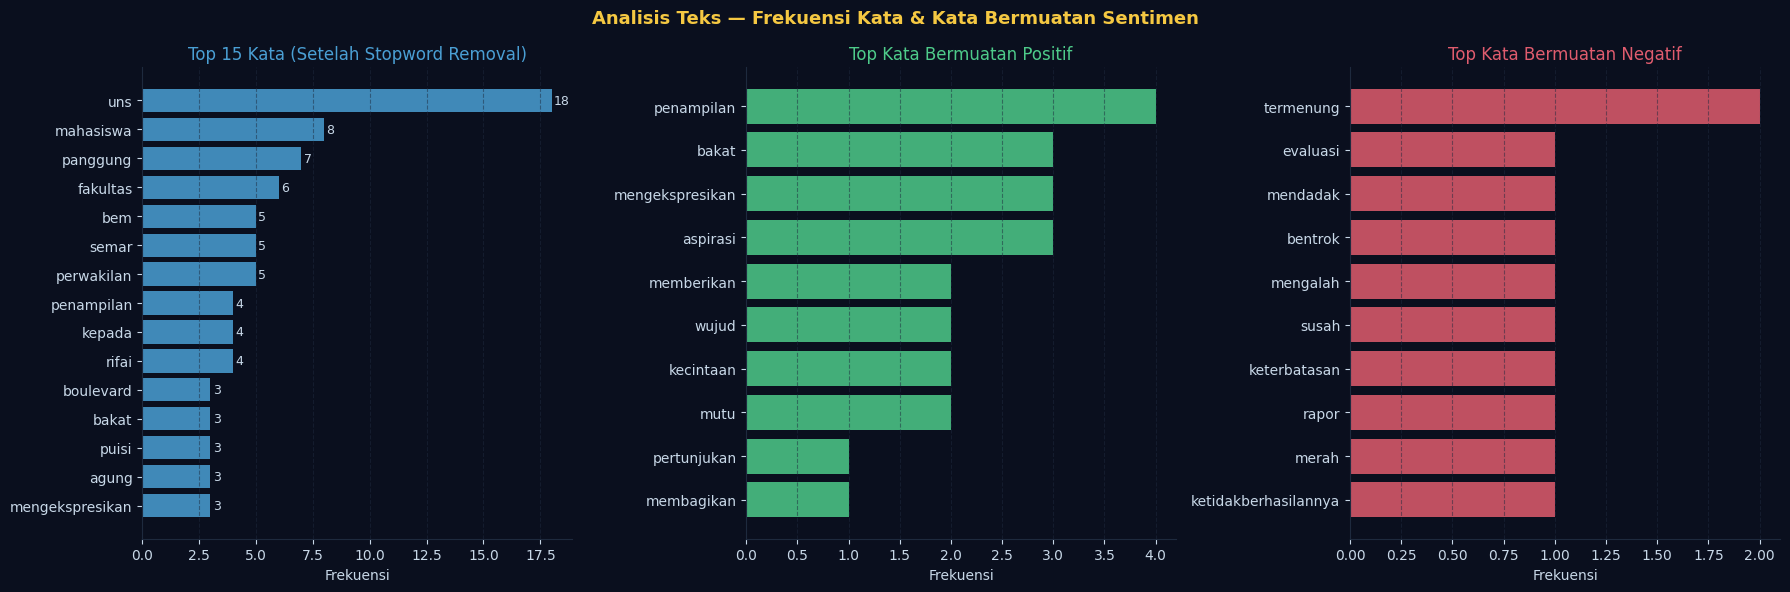

In [11]:
# ─── Plot 1: Word Frequency & Sentiment Words ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analisis Teks — Frekuensi Kata & Kata Bermuatan Sentimen',
             color=YELLOW, fontsize=13, fontweight='bold')

# Top 15 kata paling sering
top15 = token_freq.most_common(15)
words15, counts15 = zip(*top15)
bars = axes[0].barh(list(words15)[::-1], list(counts15)[::-1],
                    color=BLUE, alpha=0.85)
for bar, val in zip(bars, list(counts15)[::-1]):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=9)
axes[0].set_title('Top 15 Kata (Setelah Stopword Removal)', color=BLUE)
axes[0].set_xlabel('Frekuensi')
axes[0].grid(axis='x')

# Kata positif
all_pos = []
for r in [sentiment_score(p) for p in df_para['text']]:
    all_pos.extend(r['pos_words'])
pos_freq = Counter([w for w in all_pos if not w.startswith('~')]).most_common(10)
if pos_freq:
    pw, pv = zip(*pos_freq)
    axes[1].barh(list(pw)[::-1], list(pv)[::-1], color=GREEN, alpha=0.85)
axes[1].set_title('Top Kata Bermuatan Positif', color=GREEN)
axes[1].set_xlabel('Frekuensi')
axes[1].grid(axis='x')

# Kata negatif
all_neg = []
for r in [sentiment_score(p) for p in df_para['text']]:
    all_neg.extend(r['neg_words'])
neg_freq = Counter([w for w in all_neg if not w.startswith('~')]).most_common(10)
if neg_freq:
    nw, nv = zip(*neg_freq)
    axes[2].barh(list(nw)[::-1], list(nv)[::-1], color=RED, alpha=0.85)
axes[2].set_title('Top Kata Bermuatan Negatif', color=RED)
axes[2].set_xlabel('Frekuensi')
axes[2].grid(axis='x')

plt.tight_layout()
plt.savefig('word_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0a0f1e')
plt.show()

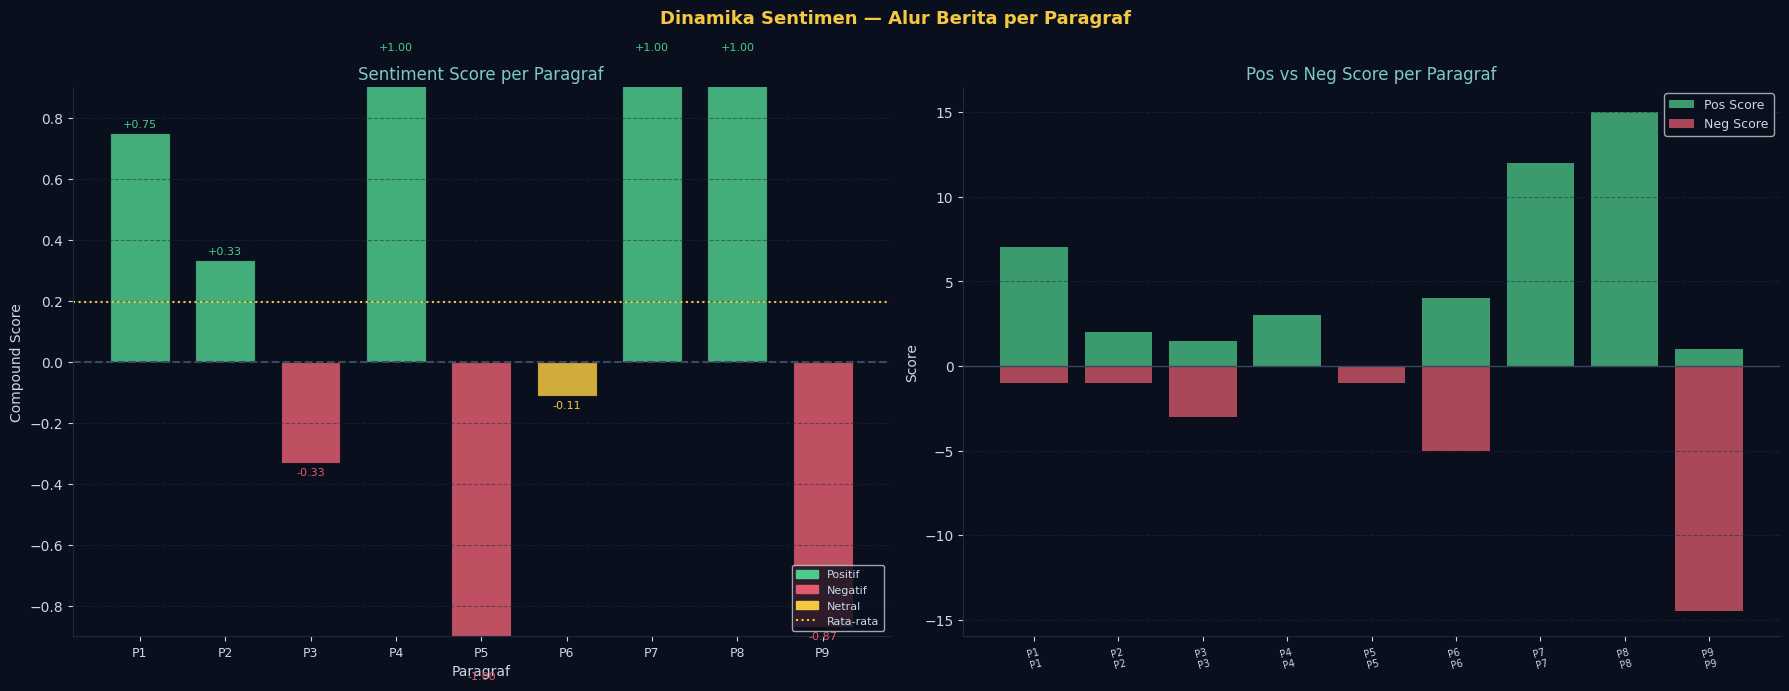

In [12]:
# ─── Plot 2: Sentiment Timeline & Per-Paragraph Heatmap ───────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Dinamika Sentimen — Alur Berita per Paragraf',
             color=YELLOW, fontsize=13, fontweight='bold')

# Sentiment flow (compound score)
bar_colors = [SENT_COLORS[l] for l in df_para['label_sent']]
bars = axes[0].bar(df_para['id'], df_para['compound'],
                   color=bar_colors, alpha=0.85, width=0.7,
                   edgecolor='#0a0f1e', linewidth=0.8)
axes[0].axhline(0, color='#3a4a5e', linewidth=1.5, linestyle='--')
axes[0].axhline(df_para['compound'].mean(), color=YELLOW, linewidth=1.5,
                linestyle=':', label=f'Rata-rata: {df_para["compound"].mean():.3f}')

for bar, (_, row) in zip(bars, df_para.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + (0.02 if bar.get_height()>=0 else -0.04),
                 f'{row["compound"]:+.2f}', ha='center', fontsize=8,
                 color=bar_colors[row['id']-1])

axes[0].set_xticks(df_para['id'])
axes[0].set_xticklabels([f'P{i}' for i in df_para['id']], fontsize=9)
axes[0].set_xlabel('Paragraf')
axes[0].set_ylabel('Compound Score')
axes[0].set_title('Sentiment Score per Paragraf', color=TEAL)
axes[0].set_ylim(-0.9, 0.9)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y')

legend_patches = [mpatches.Patch(color=c, label=l)
                  for l, c in SENT_COLORS.items()]
axes[0].legend(handles=legend_patches + [plt.Line2D([0],[0],
               color=YELLOW, linestyle=':', label='Rata-rata')],
               fontsize=8, loc='lower right')

# Stacked bar: pos vs neg per paragraf
x = np.arange(len(df_para))
axes[1].bar(x, df_para['pos_score'], color=GREEN, alpha=0.75, label='Pos Score')
axes[1].bar(x, -df_para['neg_score'], color=RED, alpha=0.75, label='Neg Score')
axes[1].axhline(0, color='#3a4a5e', linewidth=1)
axes[1].set_xticks(x)
short_labels = [f'P{row["id"]}\n{row["label"].split("—")[0].split(":")[0].strip()[:15]}'
                for _, row in df_para.iterrows()]
axes[1].set_xticklabels(short_labels, fontsize=7, rotation=15)
axes[1].set_ylabel('Score')
axes[1].set_title('Pos vs Neg Score per Paragraf', color=TEAL)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig('sentiment_flow.png', dpi=150, bbox_inches='tight', facecolor='#0a0f1e')
plt.show()

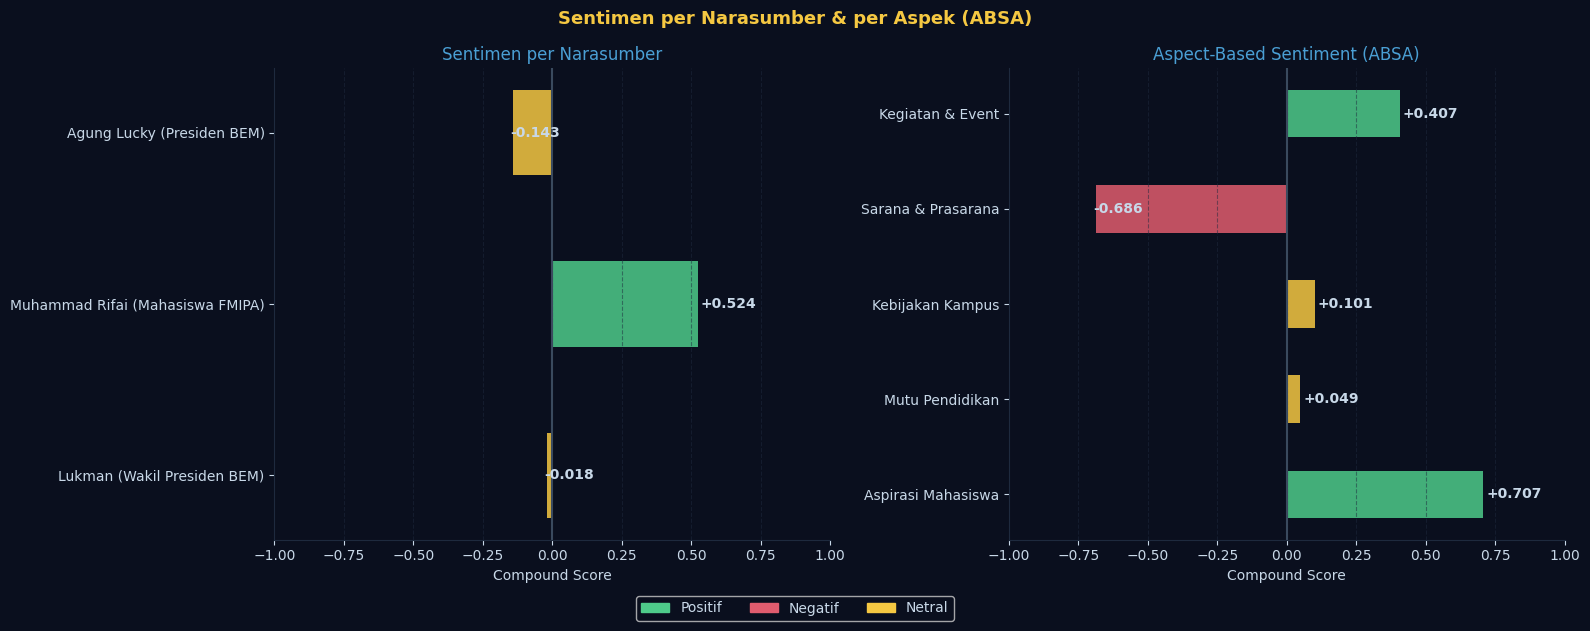

In [13]:
# ─── Plot 3: Narasumber & ABSA ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sentimen per Narasumber & per Aspek (ABSA)',
             color=YELLOW, fontsize=13, fontweight='bold')

# Narasumber
nar_names = [n.replace('\n',' ') for n in df_narrator['narasumber']]
nar_colors = [SENT_COLORS[l] for l in df_narrator['label']]
bars = axes[0].barh(nar_names[::-1], df_narrator['compound'][::-1],
                    color=nar_colors[::-1], alpha=0.85, height=0.5)
for bar, val in zip(bars, df_narrator['compound'][::-1]):
    axes[0].text(bar.get_width() + (0.01 if bar.get_width()>=0 else -0.01),
                 bar.get_y()+bar.get_height()/2,
                 f'{val:+.3f}', va='center', fontsize=10, fontweight='bold')
axes[0].axvline(0, color='#3a4a5e', linewidth=1.5)
axes[0].set_xlabel('Compound Score')
axes[0].set_title('Sentimen per Narasumber', color=BLUE)
axes[0].set_xlim(-1, 1)
axes[0].grid(axis='x')

# ABSA
absa_colors = [SENT_COLORS[r['label']] for r in absa_results.values()]
absa_compounds = [r['compound'] for r in absa_results.values()]
absa_names = list(absa_results.keys())

bars2 = axes[1].barh(absa_names[::-1], absa_compounds[::-1],
                     color=absa_colors[::-1], alpha=0.85, height=0.5)
for bar, val in zip(bars2, absa_compounds[::-1]):
    axes[1].text(bar.get_width() + (0.01 if bar.get_width()>=0 else -0.01),
                 bar.get_y()+bar.get_height()/2,
                 f'{val:+.3f}', va='center', fontsize=10, fontweight='bold')
axes[1].axvline(0, color='#3a4a5e', linewidth=1.5)
axes[1].set_xlabel('Compound Score')
axes[1].set_title('Aspect-Based Sentiment (ABSA)', color=BLUE)
axes[1].set_xlim(-1, 1)
axes[1].grid(axis='x')

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in SENT_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout()
plt.savefig('narrator_absa.png', dpi=150, bbox_inches='tight', facecolor='#0a0f1e')
plt.show()

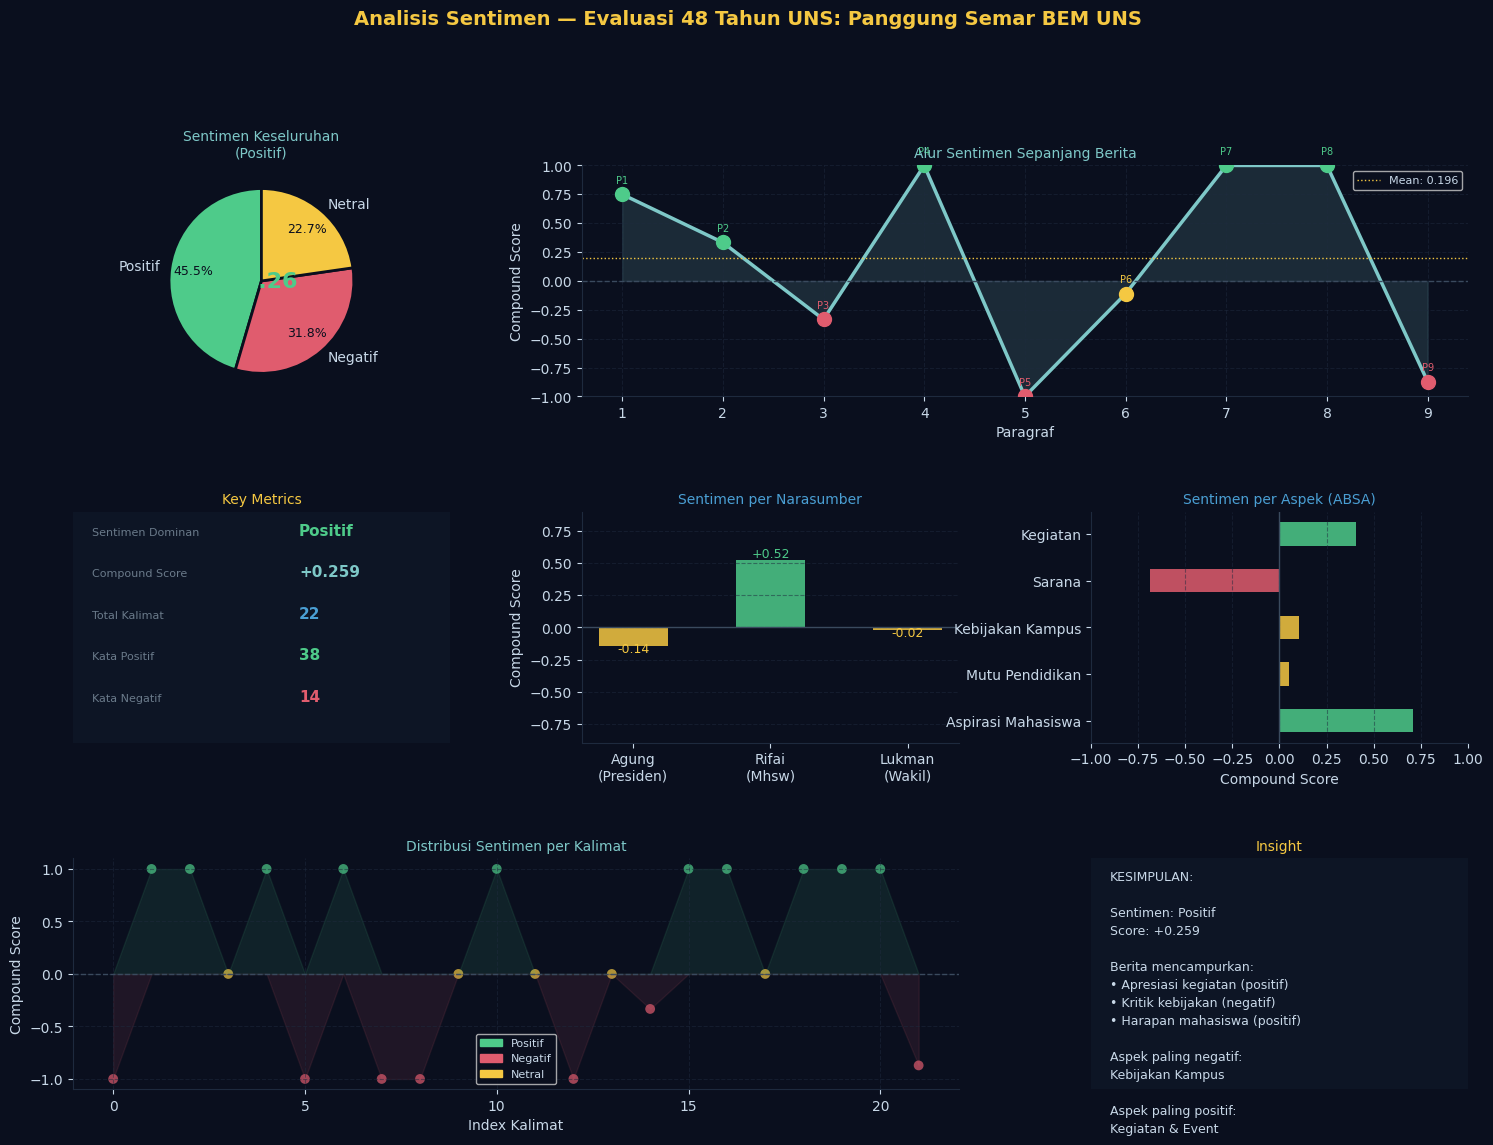

In [14]:
# ─── Plot 4: Executive Summary Dashboard ──────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle('Analisis Sentimen — Evaluasi 48 Tahun UNS: Panggung Semar BEM UNS',
             color=YELLOW, fontsize=14, fontweight='bold', y=1.01)

# 1. Overall sentiment donut
overall = sentiment_score(RAW_TEXT)
ax1 = fig.add_subplot(gs[0, 0])
sent_dist = df_sent['label'].value_counts()
wedge_colors = [SENT_COLORS[l] for l in sent_dist.index]
wedges, texts, pcts = ax1.pie(
    sent_dist.values, labels=sent_dist.index,
    colors=wedge_colors, autopct='%1.1f%%',
    pctdistance=0.75, startangle=90,
    wedgeprops=dict(edgecolor='#0a0f1e', linewidth=2),
)
for t in pcts: t.set_color('#0a0f1e'); t.set_fontsize(9)
ax1.text(0, 0, f'{overall["compound"]:+.2f}', ha='center', va='center',
         fontsize=16, fontweight='bold',
         color=GREEN if overall['compound']>0 else (RED if overall['compound']<0 else YELLOW))
ax1.set_title(f'Sentimen Keseluruhan\n({overall["label"]})', color=TEAL, fontsize=10)

# 2. Sentiment flow line
ax2 = fig.add_subplot(gs[0, 1:])
ax2.plot(df_para['id'], df_para['compound'], 'o-',
         color=TEAL, linewidth=2.5, markersize=8, markerfacecolor='white')
for _, row in df_para.iterrows():
    c = SENT_COLORS[row['label_sent']]
    ax2.scatter(row['id'], row['compound'], s=100, color=c, zorder=5)
    ax2.annotate(f"P{row['id']}", (row['id'], row['compound']),
                 textcoords='offset points', xytext=(0,8),
                 fontsize=7, ha='center', color=c)
ax2.fill_between(df_para['id'], df_para['compound'], alpha=0.15, color=TEAL)
ax2.axhline(0, color='#3a4a5e', linewidth=1, linestyle='--')
ax2.axhline(df_para['compound'].mean(), color=YELLOW, linewidth=1,
            linestyle=':', label=f'Mean: {df_para["compound"].mean():.3f}')
ax2.set_xlabel('Paragraf')
ax2.set_ylabel('Compound Score')
ax2.set_title('Alur Sentimen Sepanjang Berita', color=TEAL, fontsize=10)
ax2.set_ylim(-1, 1)
ax2.set_xticks(df_para['id'])
ax2.legend(fontsize=8)
ax2.grid(True)

# 3. KPI cards (teks)
ax3 = fig.add_subplot(gs[1, 0])
ax3.axis('off')
kpi_texts = [
    ('Sentimen Dominan', overall['label'],
     SENT_COLORS[overall['label']]),
    ('Compound Score', f"{overall['compound']:+.3f}", TEAL),
    ('Total Kalimat', str(len(df_sent)), BLUE),
    ('Kata Positif', str(len([w for ws in [r['pos_words'] for r in [sentiment_score(p) for p in df_para['text']]] for w in ws if not w.startswith('~')])), GREEN),
    ('Kata Negatif', str(len([w for ws in [r['neg_words'] for r in [sentiment_score(p) for p in df_para['text']]] for w in ws if not w.startswith('~')])), RED),
]
for i, (label, val, color) in enumerate(kpi_texts):
    ax3.text(0.05, 0.9 - i*0.18, label, transform=ax3.transAxes,
             fontsize=8, color=GRAY)
    ax3.text(0.6, 0.9 - i*0.18, val, transform=ax3.transAxes,
             fontsize=11, fontweight='bold', color=color)
ax3.set_title('Key Metrics', color=YELLOW, fontsize=10)
ax3.add_patch(mpatches.FancyBboxPatch((0,0),1,1,
    boxstyle='round,pad=0.02', facecolor='#0d1525',
    edgecolor='#1e2a3e', transform=ax3.transAxes, zorder=0))

# 4. Narasumber bar
ax4 = fig.add_subplot(gs[1, 1])
nar_short = ['Agung\n(Presiden)', 'Rifai\n(Mhsw)', 'Lukman\n(Wakil)']
nar_cols  = [SENT_COLORS[l] for l in df_narrator['label']]
ax4.bar(nar_short, df_narrator['compound'], color=nar_cols, alpha=0.85, width=0.5)
ax4.axhline(0, color='#3a4a5e', linewidth=1)
for i, (name, val) in enumerate(zip(nar_short, df_narrator['compound'])):
    ax4.text(i, val + (0.02 if val>=0 else -0.05), f'{val:+.2f}',
             ha='center', fontsize=9, color=nar_cols[i])
ax4.set_ylabel('Compound Score')
ax4.set_title('Sentimen per Narasumber', color=BLUE, fontsize=10)
ax4.set_ylim(-0.9, 0.9)
ax4.grid(axis='y')

# 5. ABSA horizontal
ax5 = fig.add_subplot(gs[1, 2])
absa_names_short = [a.split('&')[0].strip() for a in absa_names]
absa_cols = [SENT_COLORS[r['label']] for r in absa_results.values()]
ax5.barh(absa_names_short[::-1], absa_compounds[::-1],
         color=absa_cols[::-1], alpha=0.85, height=0.5)
ax5.axvline(0, color='#3a4a5e', linewidth=1)
ax5.set_xlabel('Compound Score')
ax5.set_title('Sentimen per Aspek (ABSA)', color=BLUE, fontsize=10)
ax5.set_xlim(-1, 1)
ax5.grid(axis='x')

# 6. Sentence-level distribution
ax6 = fig.add_subplot(gs[2, :2])
ax6.scatter(range(len(df_sent)), df_sent['compound'],
            c=[SENT_COLORS[l] for l in df_sent['label']],
            s=50, alpha=0.7, edgecolors='none')
ax6.axhline(0, color='#3a4a5e', linewidth=1, linestyle='--')
ax6.fill_between(range(len(df_sent)), df_sent['compound'].clip(lower=0), alpha=0.1, color=GREEN)
ax6.fill_between(range(len(df_sent)), df_sent['compound'].clip(upper=0), alpha=0.1, color=RED)
ax6.set_xlabel('Index Kalimat')
ax6.set_ylabel('Compound Score')
ax6.set_title('Distribusi Sentimen per Kalimat', color=TEAL, fontsize=10)
ax6.grid(True)
legend_p = [mpatches.Patch(color=c, label=l) for l, c in SENT_COLORS.items()]
ax6.legend(handles=legend_p, fontsize=8)

# 7. Summary insight box
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
insight_text = (
    f"KESIMPULAN:\n\n"
    f"Sentimen: {overall['label']}\n"
    f"Score: {overall['compound']:+.3f}\n\n"
    f"Berita mencampurkan:\n"
    f"• Apresiasi kegiatan (positif)\n"
    f"• Kritik kebijakan (negatif)\n"
    f"• Harapan mahasiswa (positif)\n\n"
    f"Aspek paling negatif:\n"
    f"Kebijakan Kampus\n\n"
    f"Aspek paling positif:\n"
    f"Kegiatan & Event"
)
ax7.text(0.05, 0.95, insight_text, transform=ax7.transAxes,
         fontsize=9, va='top', color='#c8d8e8', linespacing=1.5)
ax7.add_patch(mpatches.FancyBboxPatch((0,0),1,1,
    boxstyle='round,pad=0.02', facecolor='#0d1525',
    edgecolor=YELLOW, linewidth=1.5, transform=ax7.transAxes, zorder=0))
ax7.set_title('Insight', color=YELLOW, fontsize=10)

plt.savefig('sentiment_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0a0f1e')
plt.show()

---
## 📌 Section 5 — Summary & Interpretasi

In [16]:
# ─── Final Summary ────────────────────────────────────────────────
overall = sentiment_score(RAW_TEXT)

print('=' * 65)
print('HASIL ANALISIS SENTIMEN — EVALUASI 48 TAHUN UNS')
print('=' * 65)

print(f"""
SUMBER BERITA
   Judul  : Evaluasi 48 Tahun UNS: Aliansi BEM UNS Gelar Panggung SEMAR
   Tanggal: 25 Maret 2024
   URL    : https://saluransebelas.com/evaluasi-48-tahun-uns-aliansi-bem-uns-gelar-panggung-semar-dan-bagi-takjil/

SENTIMEN KESELURUHAN
   Label       : {overall['label']}
   Compound    : {overall['compound']:+.4f}
   Pos Score   : {overall['pos_score']}
   Neg Score   : {overall['neg_score']}
""")

print('SENTIMEN PER PARAGRAF')
for _, row in df_para.iterrows():
    emoji = '🟢' if row['label_sent']=='Positif' else ('🔴' if row['label_sent']=='Negatif' else '🟡')
    print(f"  {emoji} P{row['id']}: {row['label']:<40} [{row['compound']:+.3f}]")

print('\nSENTIMEN PER NARASUMBER')
for _, row in df_narrator.iterrows():
    emoji = '🟢' if row['label']=='Positif' else ('🔴' if row['label']=='Negatif' else '🟡')
    name_clean = row['narasumber'].replace('\n',' ')
    print(f"  {emoji} {name_clean:<35} [{row['compound']:+.3f}] {row['label']}")

print('\n🔍 ASPECT-BASED SENTIMENT (ABSA)')
for asp, r in absa_results.items():
    emoji = '🟢' if r['label']=='Positif' else ('🔴' if r['label']=='Negatif' else '🟡')
    print(f"  {emoji} {asp:<35} [{r['compound']:+.3f}] {r['label']}")

print(f"""
INTERPRETASI
   Berita ini menggambarkan dualitas: di satu sisi ada SEMANGAT dan KECINTAAN
   mahasiswa terhadap kampus yang tercermin lewat kegiatan Panggung Semar,
   di sisi lain ada KRITIK NYATA terhadap kebijakan kampus yang diwujudkan
   dalam simbol 'rapor merah' dari aliansi BEM UNS.

   Aspek paling positif : Kegiatan & Event (antusiasme & ekspresi mahasiswa)
   Aspek paling negatif : Kebijakan Kampus (rapor merah, SPI, sarana-prasarana)
   Narasumber paling kritis : Lukman (Wakil Presiden BEM)
   Narasumber paling positif: Agung (Presiden BEM) — tone netral-positif

   Muhammad Rifai (FMIPA Statistika) menyampaikan perspektif CAMPURAN:
   bangga masuk UNS namun terhambat keterbatasan dalam berekspresi.
   Harapannya untuk UNS lebih maju dan terbuka menunjukkan optimisme konstruktif.
""")

print('=' * 65)
print('Tools: Python · Lexicon-Based NLP · ABSA · Pandas · Matplotlib')
print('Portfolio | Muhammad Rifai | Data Analytics')
print('=' * 65)

HASIL ANALISIS SENTIMEN — EVALUASI 48 TAHUN UNS

SUMBER BERITA
   Judul  : Evaluasi 48 Tahun UNS: Aliansi BEM UNS Gelar Panggung SEMAR
   Tanggal: 25 Maret 2024
   URL    : https://saluransebelas.com/evaluasi-48-tahun-uns-aliansi-bem-uns-gelar-panggung-semar-dan-bagi-takjil/

SENTIMEN KESELURUHAN
   Label       : Positif
   Compound    : +0.2587
   Pos Score   : 45.0
   Neg Score   : 26.5

SENTIMEN PER PARAGRAF
  🟢 P1: P1: Pembukaan — Deskripsi Acara          [+0.750]
  🟢 P2: P2: Pernyataan Agung (Presiden BEM) — Konteks Lokasi [+0.333]
  🔴 P3: P3: Kutipan Agung — Perubahan Lokasi     [-0.333]
  🟢 P4: P4: Rundown Acara — Penampilan Tiap Fakultas [+1.000]
  🔴 P5: P5: Profil Rifai — Perwakilan FMIPA      [-1.000]
  🟡 P6: P6: Kutipan Rifai — Makna Puisi Termenung [-0.111]
  🟢 P7: P7: Harapan Rifai untuk UNS              [+1.000]
  🟢 P8: P8: Pernyataan Lukman (Wakil Presiden BEM) [+1.000]
  🔴 P9: P9: Kutipan Lukman — Rapor Merah UNS     [-0.871]

SENTIMEN PER NARASUMBER
  🟡 Agung Lucky (Pr

---

## 🛠️ Metodologi Detail

| Komponen | Detail |
|---|---|
| **Preprocessing** | Tokenisasi regex, lowercase, stopword removal (custom Bahasa Indonesia) |
| **Sentiment Engine** | Lexicon-based scoring dengan bobot (1–3), negasi handling, intensifier multiplier |
| **Kamus Sentimen** | 30+ kata positif · 25+ kata negatif, domain kampus & berita |
| **Unit Analisis** | Teks keseluruhan → Paragraf → Kalimat → Narasumber → Aspek |
| **ABSA** | 5 aspek: Kegiatan, Sarana, Kebijakan, Mutu Pendidikan, Aspirasi Mahasiswa |
| **Visualisasi** | 4 panel plot: word analysis, sentiment flow, narrator/ABSA, executive dashboard |

## 📦 Libraries
`pandas` · `numpy` · `matplotlib` · `seaborn` · `re` · `collections`

---
*Portfolio | Muhammad Rifai | Data Analytics*  
*Sumber: [saluransebelas.com](https://saluransebelas.com/evaluasi-48-tahun-uns-aliansi-bem-uns-gelar-panggung-semar-dan-bagi-takjil/)*